# Final Model Evaluation

This notebook evaluates the selected neural network architecture on the previously untouched test dataset and reports the final classification performance.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [47]:
np.random.seed(42)
tf.random.set_seed(42)

In [48]:
data_path = Path("../data/Datasets.xlsx")

df = pd.read_excel(
    data_path,
    sheet_name="Recruitment"
)

X = df.drop(columns=["Candidate_ID", "Status"])
y = df["Status"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [49]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [50]:
numerical_features = [
    "Experience",
    "Tech_Score",
    "Interview"
]

categorical_features = [
    "Position"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

input_size = X_train_processed.shape[1]

In [51]:
final_model = Sequential([
    tf.keras.Input(shape=(input_size,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

In [52]:
final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
final_history = final_model.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_val_processed,
        y_val
    ),
    epochs=100,
    batch_size=16,
    verbose=0
)

In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 53.33%
Final Test Loss: 0.6531


In [ ]:
test_probabilities = final_model.predict(
    X_test_processed
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [ ]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    test_predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted"
)

print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

Accuracy:  53.33%
Precision: 53.33%
Recall:    53.33%
F1 Score:  53.33%


In [ ]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00        10
     Pending       0.30      0.30      0.30        10
    Rejected       0.30      0.30      0.30        10

    accuracy                           0.53        30
   macro avg       0.53      0.53      0.53        30
weighted avg       0.53      0.53      0.53        30



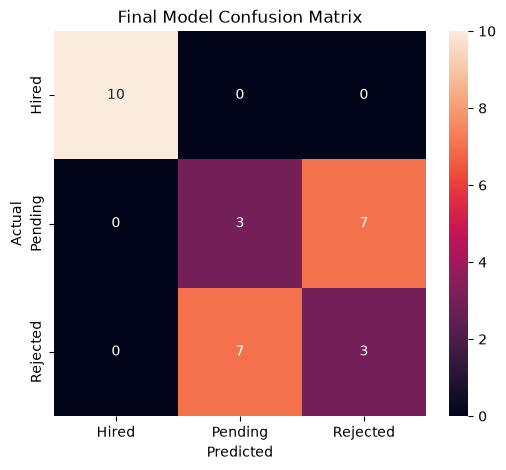

In [ ]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

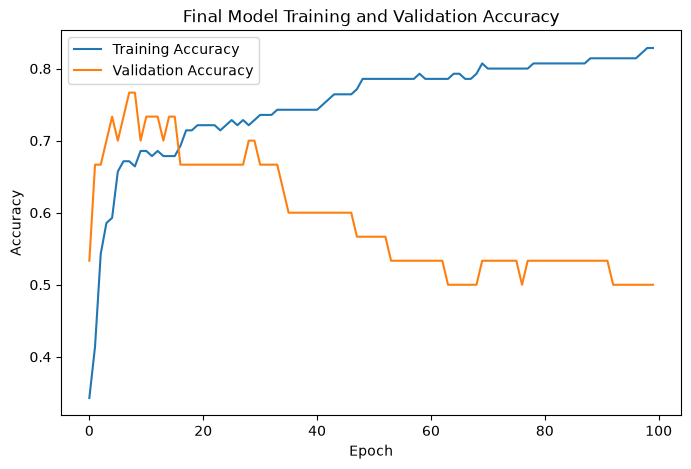

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Final Model Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

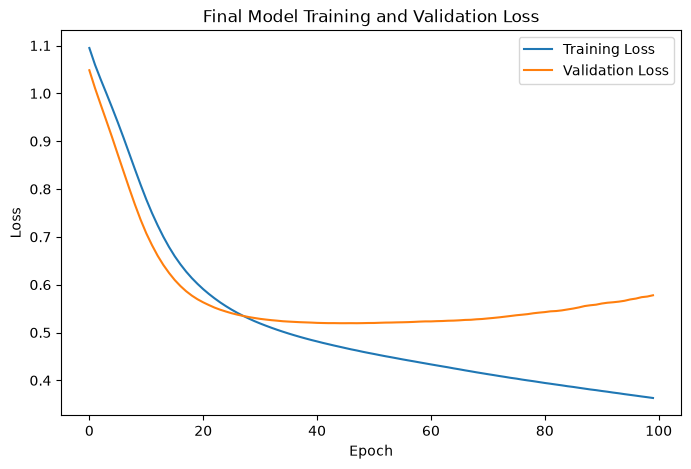

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Final Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
final_model.save(
    "../models/recruitment_classifier.keras"
)

In [ ]:
import joblib

In [ ]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

print("Preprocessor and label encoder saved successfully.")

Preprocessor and label encoder saved successfully.


In [ ]:
print("CLASSIFICATION REPORT")
print("---------------------")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00        10
     Pending       0.30      0.30      0.30        10
    Rejected       0.30      0.30      0.30        10

    accuracy                           0.53        30
   macro avg       0.53      0.53      0.53        30
weighted avg       0.53      0.53      0.53        30



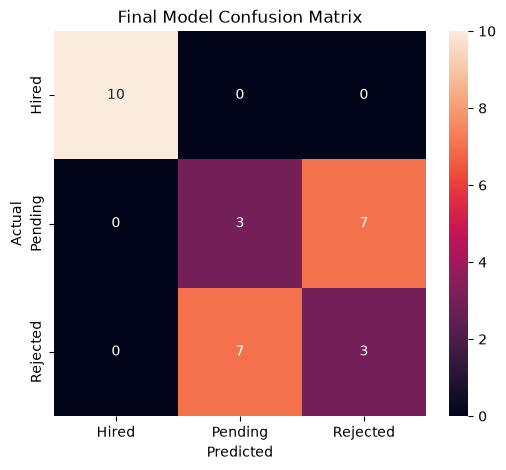

In [ ]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Error Analysis

In [ ]:
status_analysis = df.groupby("Status")[
    ["Experience", "Tech_Score", "Interview"]
].mean()

status_analysis.round(2)

,Experience,Tech_Score,Interview
Status,,,
Hired,4.98,83.75,81.67
Pending,4.46,64.19,61.84
Rejected,4.58,61.88,64.46


In [ ]:
status_analysis_median = df.groupby("Status")[
    ["Experience", "Tech_Score", "Interview"]
].median()

status_analysis_median.round(2)

,Experience,Tech_Score,Interview
Status,,,
Hired,5.0,84.0,81.0
Pending,4.5,61.5,60.0
Rejected,5.0,59.0,63.0


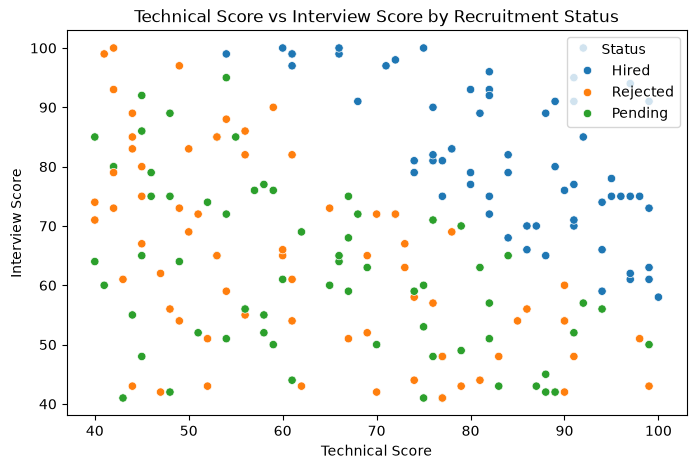

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Tech_Score",
    y="Interview",
    hue="Status"
)

plt.title("Technical Score vs Interview Score by Recruitment Status")
plt.xlabel("Technical Score")
plt.ylabel("Interview Score")
plt.show()

### Final Model Observation

The final neural network achieved 53.33% test accuracy and a weighted F1-score of 52.86%.

The confusion matrix showed that the model correctly classified all Hired candidates in the test set. However, classification performance for Pending and Rejected candidates was substantially weaker.

Most classification errors occurred between the Pending and Rejected classes, indicating that the available predictors may not provide sufficient information to clearly distinguish these two outcomes.

Additional recruitment-related features and validation on a larger independent dataset should be considered in future work to improve generalization.